In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

# Set Chinese display
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
plt.rcParams['axes.edgecolor'] = 'black'   
plt.rcParams['axes.linewidth'] = 1.0       
plt.rcParams['axes.grid'] = False        
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['xtick.major.size'] = 6   
plt.rcParams['ytick.major.size'] = 6

In [9]:
# Read data
df = pd.read_csv('csv/df_k.csv')

# Filter data with k less than 10
df_filtered = df[df['k(W/mK)'] < 10].copy()

print(f"Original data count: {len(df)}")
print(f"Filtered data count (k<10): {len(df_filtered)}")
print(f"k range: [{df_filtered['k(W/mK)'].min():.3f}, {df_filtered['k(W/mK)'].max():.3f}]")

# Prepare features and labels
# Select all features starting with MagpieData
feature_columns = [col for col in df.columns if col.startswith('MagpieData')]
X = df_filtered[feature_columns]
y = df_filtered['k(W/mK)']

# Check for missing values
print(f"Feature missing values count: {X.isnull().sum().sum()}")
print(f"Target variable missing values count: {y.isnull().sum()}")

# If there are missing values, fill with mean
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.mean())
if y.isnull().sum() > 0:
    y = y.fillna(y.mean())

Original data count: 1003
Filtered data count (k<10): 970
k range: [0.200, 9.927]
Feature missing values count: 0
Target variable missing values count: 0


In [10]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set size: (776, 132)
Testing set size: (194, 132)


In [11]:
# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [12]:
# Predict
y_train_pred = rf_model.predict(X_train_scaled)
y_test_pred = rf_model.predict(X_test_scaled)

# Evaluate model
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Training set RMSE: {train_rmse:.3f}")
print(f"Testing set RMSE: {test_rmse:.3f}")
print(f"Training set R²: {train_r2:.3f}")
print(f"Testing set R²: {test_r2:.3f}")

Training set RMSE: 0.771
Testing set RMSE: 1.132
Training set R²: 0.880
Testing set R²: 0.750


In [13]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# print("\nTop 10 important features:")
# print(feature_importance.head(10))

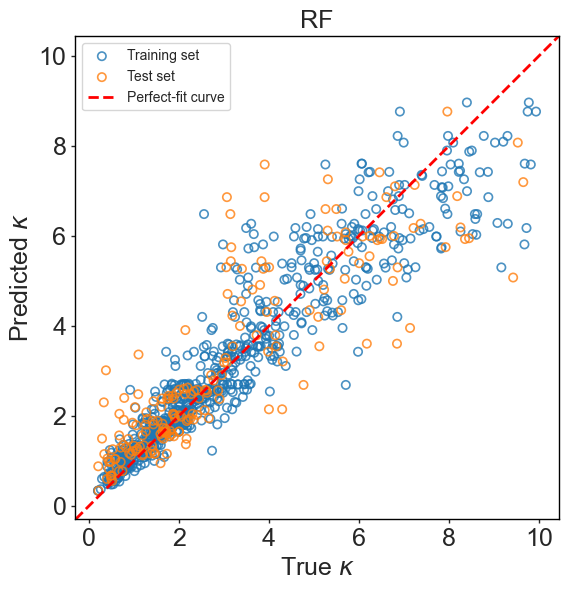

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))

# 1. Training set: hollow blue circles
ax.scatter(y_train, y_train_pred,
           facecolors='none',   # key for hollow
           edgecolors='tab:blue',
           linewidth=1.2,
           alpha=0.8,
           label='Training set')

# 2. Test set: hollow orange circles
ax.scatter(y_test, y_test_pred,
           facecolors='none',
           edgecolors='tab:orange',
           linewidth=1.2,
           alpha=0.8,
           label='Test set')

# 3. Perfect fit line
lim = [y.min() - 0.5, y.max() + 0.5]
ax.plot(lim, lim, 'r--', lw=2, label='Perfect-fit curve')

# 4. Other styling
ax.set_xlabel(r'True $\kappa$', fontsize=18)
ax.set_ylabel(r'Predicted $\kappa$', fontsize=18)
ax.set_title('RF', fontsize=18)
ax.legend()


# 6. Equal aspect ratio axes
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal', adjustable='box')

ax.tick_params(which='both',
               direction='out',
               top=False,      # turn off top
               right=False,    # turn off right
               left=True,      # turn on left
               bottom=True,    # turn on bottom
               length=3,
               width=1,
               labelsize=18)

plt.tight_layout()
plt.show()